In [1]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("mariusmarin/bs-80k")

print("Path to dataset files:", path)

100%|██████████| 697M/697M [00:06<00:00, 109MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mariusmarin/bs-80k/versions/1


In [2]:
import os

# The user identified 'temp' as the main dataset folder for the BS-80K images
dataset_root = os.path.join(path, 'temp')

if os.path.exists(dataset_root):
    print(f"Exploring dataset root: {dataset_root}")

    # List subdirectories to understand the structure (e.g., categories of metastases)
    subdirs = [d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))]
    print(f"Subdirectories found: {subdirs}")

    # Count files in the first few subdirectories to verify images
    for subdir in subdirs[:5]:
        subdir_path = os.path.join(dataset_root, subdir)
        img_count = len([f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
        print(f"- {subdir}: {img_count} images found")
else:
    print(f"The directory {dataset_root} does not exist. Current path contents: {os.listdir(path)}")

Exploring dataset root: /root/.cache/kagglehub/datasets/mariusmarin/bs-80k/versions/1/temp
Subdirectories found: ['shoRPOST', 'kneeRANT', 'headANT', 'shoLANT', 'ankleLPOST', 'vertbraPOST', 'pelvisANT', 'chestRPOST', 'pelvisPOST', 'ankleRPOST', 'chestLANT', 'kneeLANT', 'elbowLPOST', 'kneeLPOST', 'shoRANT', 'vertbraANT', 'headPOST', 'shoLPOST', 'wholeBodyPOST', 'chestLPOST', 'ankleRANT', 'elbowRANT', 'elbowRPOST', 'elbowLANT', 'chestRANT', 'kneeRPOST', 'wholeBodyANT', 'ankleLANT']
- shoRPOST: 2925 images found
- kneeRANT: 2925 images found
- headANT: 2925 images found
- shoLANT: 2925 images found
- ankleLPOST: 2925 images found


In [3]:
import os
import pandas as pd

# Configuration
dataset_root = os.path.join(path, 'temp')
all_data = []

# Iterate through each subdirectory to collect labels and paths
subdirs = [d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))]

for subdir in subdirs:
    subdir_path = os.path.join(dataset_root, subdir)
    txt_file_path = os.path.join(subdir_path, f"{subdir}.txt")

    if os.path.exists(txt_file_path):
        try:
            # Use raw string r'\s+'
            labels_df = pd.read_csv(txt_file_path, sep=r'\s+', names=['filename', 'label'], header=None)

            # Enrich metadata
            labels_df['folder'] = subdir
            labels_df['full_path'] = labels_df['filename'].apply(lambda x: os.path.join(subdir_path, x))

            all_data.append(labels_df)
        except Exception as e:
            print(f"Error reading {txt_file_path}: {e}")

# Combine into master DataFrame
if all_data:
    dataset_df = pd.concat(all_data, ignore_index=True)
    print(f"Dataset loaded with {len(dataset_df)} labeled images.")

    # Display summary statistics
    display(dataset_df.head())
    print("\nLabel distribution (0=Normal, 1=Abnormal):")
    display(dataset_df['label'].value_counts())
else:
    print("No label files were found. Please check the dataset path.")

Dataset loaded with 82545 labeled images.


,filename,label,folder,full_path
0,1000.jpg,0,shoRPOST,/root/.cache/kagglehub/datasets/mariusmarin/bs...
1,1001.jpg,0,shoRPOST,/root/.cache/kagglehub/datasets/mariusmarin/bs...
2,1002.jpg,0,shoRPOST,/root/.cache/kagglehub/datasets/mariusmarin/bs...
3,1003.jpg,0,shoRPOST,/root/.cache/kagglehub/datasets/mariusmarin/bs...
4,1004.jpg,0,shoRPOST,/root/.cache/kagglehub/datasets/mariusmarin/bs...



Label distribution (0=Normal, 1=Abnormal):


,count
label,
0,76749
1,5796


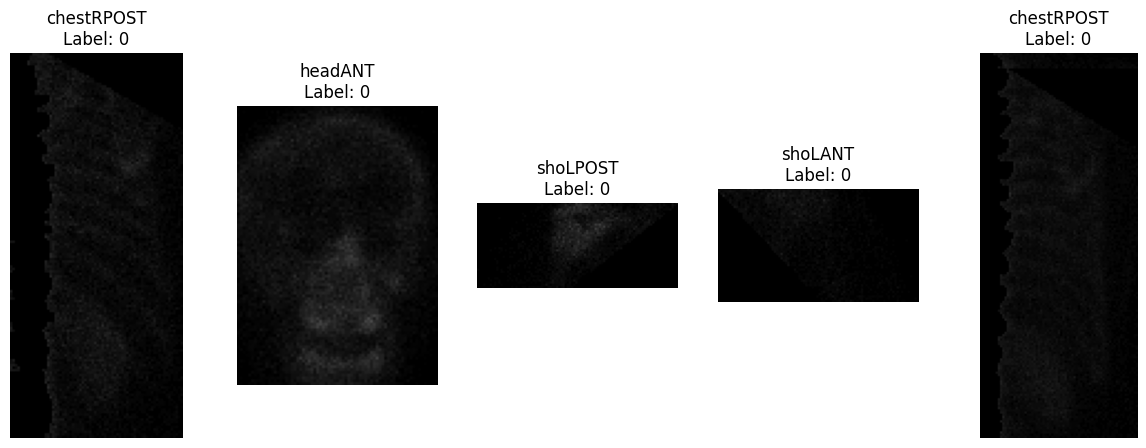

In [4]:
import matplotlib.pyplot as plt
import cv2

def show_samples(df, n=5):
    plt.figure(figsize=(15, 5))
    samples = df.sample(n)
    for i, (idx, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row['full_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{row['folder']}\nLabel: {row['label']}")
        plt.axis('off')
    plt.show()

# Show some random samples from the loaded dataset
if not dataset_df.empty:
    show_samples(dataset_df)

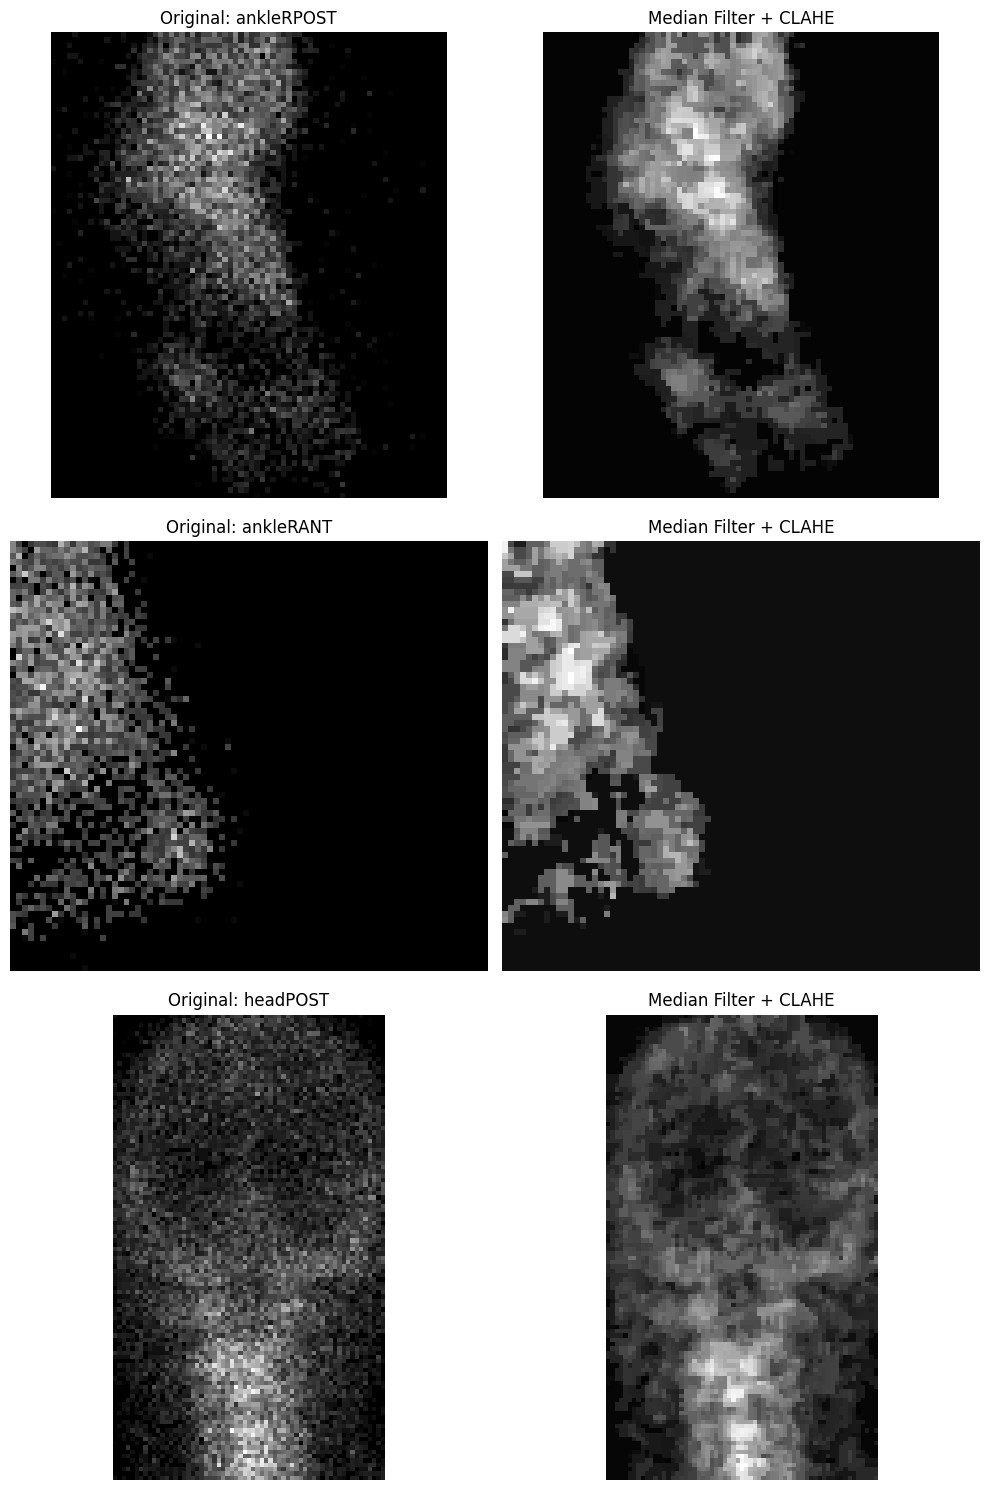

In [5]:
import numpy as np

def preprocess_image(img_path):
    # Load image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # 1. Noise Reduction: Median Filter
    denoised = cv2.medianBlur(img, 3)

    # 2. Contrast Enhancement: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    return img, enhanced

# Visualize the effect on a few samples
samples = dataset_df.sample(3)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i, (idx, row) in enumerate(samples.iterrows()):
    original, processed = preprocess_image(row['full_path'])

    axes[i, 0].imshow(original, cmap='gray')
    axes[i, 0].set_title(f"Original: {row['folder']}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(processed, cmap='gray')
    axes[i, 1].set_title("Median Filter + CLAHE")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

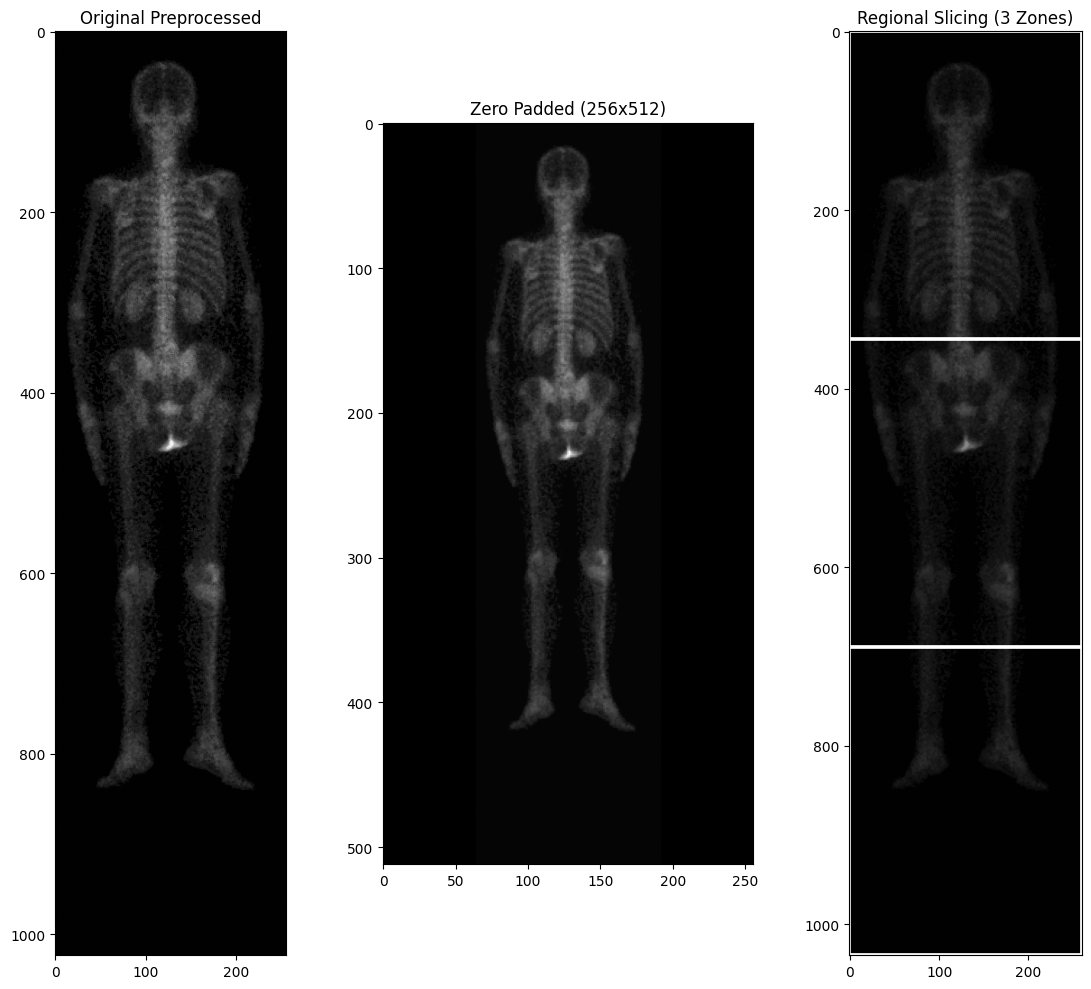

In [7]:
def resize_with_padding(img, target_size=(224, 224)):
    """Resizes image keeping aspect ratio by adding zero padding."""
    h, w = img.shape[:2]
    target_w, target_h = target_size

    # Calculate scale
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)

    # Resize image
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Create canvas and paste resized image
    canvas = np.zeros((target_h, target_w), dtype=np.uint8)
    top = (target_h - new_h) // 2
    left = (target_w - new_w) // 2
    canvas[top:top+new_h, left:left+new_w] = resized

    return canvas

def slice_image(img, rows=2, cols=2):
    """Slices the image into a grid of patches for regional analysis."""
    h, w = img.shape[:2]
    patch_h, patch_w = h // rows, w // cols
    patches = []

    for i in range(rows):
        for j in range(cols):
            patch = img[i*patch_h:(i+1)*patch_h, j*patch_w:(j+1)*patch_w]
            patches.append(patch)

    return patches

# --- Demonstration with a Whole Body Scan ---
# Find a wholeBody scan for better demonstration of slicing
wb_sample = dataset_df[dataset_df['folder'].str.contains('wholeBody', case=False)].iloc[0]
_, enhanced = preprocess_image(wb_sample['full_path'])

# 1. Padding Demo
padded = resize_with_padding(enhanced, (256, 512))

# 2. Slicing Demo (e.g., Head, Thorax, Pelvis, Legs)
patches = slice_image(enhanced, rows=3, cols=1)

# Visualization
plt.figure(figsize=(12, 10))
plt.subplot(1, 3, 1)
plt.imshow(enhanced, cmap='gray')
plt.title("Original Preprocessed")

plt.subplot(1, 3, 2)
plt.imshow(padded, cmap='gray')
plt.title("Zero Padded (256x512)")

plt.subplot(1, 3, 3)
# Show patches stacked vertically for the WB scan
combined_patches = np.vstack([cv2.copyMakeBorder(p, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=255) for p in patches])
plt.imshow(combined_patches, cmap='gray')
plt.title("Regional Slicing (3 Zones)")

plt.tight_layout()
plt.show()

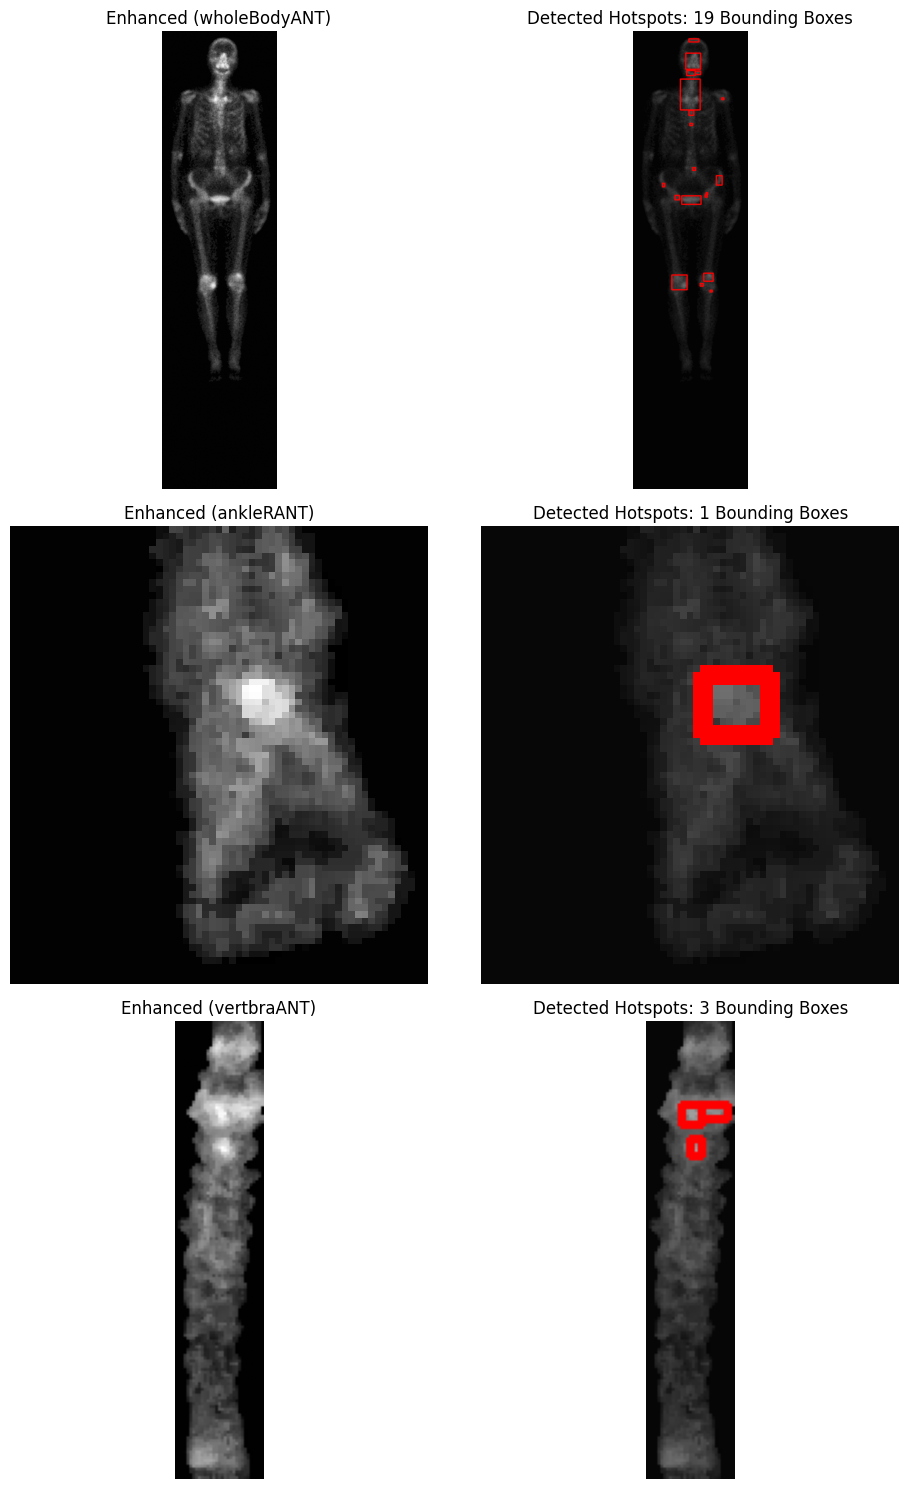

In [13]:
def detect_and_draw_boxes_dynamic(img_path, percentile_cutoff=98.5):
    # 1. Load and preprocess image
    img_raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_raw is None:
        return None, None, 0

    denoised = cv2.medianBlur(img_raw, 3)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_enhanced = clahe.apply(denoised)

    # 2. Dynamic thresholding based on intensity distribution
    threshold_val = np.percentile(img_enhanced, percentile_cutoff)
    _, thresh = cv2.threshold(img_enhanced, threshold_val, 255, cv2.THRESH_BINARY)

    # 3. Find contours of active regions
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Convert original to RGB for plotting colored boxes
    img_with_boxes = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2RGB)

    box_count = 0
    for contour in contours:
        # Filter out minor noise
        if cv2.contourArea(contour) > 5:
            x, y, w, h = cv2.boundingRect(contour)
            # Draw bounding box (Red color, thickness 2)
            cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (255, 0, 0), 2)
            box_count += 1

    return img_enhanced, img_with_boxes, box_count

# Visualize adjusted bounding boxes on the same abnormal (metastasis) samples
fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i, (idx, row) in enumerate(abnormal_samples.iterrows()):
    enhanced, boxed, count = detect_and_draw_boxes_dynamic(row['full_path'])

    if enhanced is not None:
        axes[i, 0].imshow(enhanced, cmap='gray')
        axes[i, 0].set_title(f"Enhanced ({row['folder']})")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(boxed)
        axes[i, 1].set_title(f"Detected Hotspots: {count} Bounding Boxes")
        axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# --- Controlled Change Experiment Setup ---
# Task: Classify Head Scans (headANT) as Normal (0) vs. Abnormal (1)
# Controlled variable: Raw Unfiltered Images vs. Preprocessed Images (Median Filter + CLAHE)

print("Extracting subset data for the controlled experiment...")
subset_df = dataset_df[dataset_df['folder'] == 'headANT'].sample(1000, random_state=42)

def extract_features(img):
    # Simple, highly robust statistical features suited for global bone scintigraphy patterns
    return [np.mean(img), np.std(img), np.percentile(img, 90), np.percentile(img, 95), np.percentile(img, 99)]

X_raw = []
X_prep = []
y = []

for idx, row in subset_df.iterrows():
    raw_img = cv2.imread(row['full_path'], cv2.IMREAD_GRAYSCALE)
    if raw_img is None:
        continue

    # Preprocess image
    denoised = cv2.medianBlur(raw_img, 3)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    prep_img = clahe.apply(denoised)

    # Resize both to a common shape to keep spatial density consistency
    raw_resized = cv2.resize(raw_img, (128, 128))
    prep_resized = cv2.resize(prep_img, (128, 128))

    X_raw.append(extract_features(raw_resized))
    X_prep.append(extract_features(prep_resized))
    y.append(row['label'])

X_raw = np.array(X_raw)
X_prep = np.array(X_prep)
y = np.array(y)

print(f"Feature matrix extracted for {len(y)} samples.")

Extracting subset data for the controlled experiment...
Feature matrix extracted for 1000 samples.


In [9]:
# Train and compare classifiers
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42)
X_train_prep, X_test_prep, _, _ = train_test_split(X_prep, y, test_size=0.3, random_state=42)

# Classifier for RAW images
clf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
clf_raw.fit(X_train_raw, y_train)
y_pred_raw = clf_raw.predict(X_test_raw)
acc_raw = accuracy_score(y_test, y_pred_raw)

# Classifier for PREPROCESSED images
clf_prep = RandomForestClassifier(n_estimators=100, random_state=42)
clf_prep.fit(X_train_prep, y_train)
y_pred_prep = clf_prep.predict(X_test_prep)
acc_prep = accuracy_score(y_test, y_pred_prep)

print("=== CONTROLLED EXPERIMENT RESULTS ===")
print(f"Accuracy on Raw Unfiltered Images: {acc_raw:.4f}")
print(f"Accuracy on Preprocessed Images (Median Filter + CLAHE): {acc_prep:.4f}")
print("\nDetailed report for Raw Images:")
print(classification_report(y_test, y_pred_raw))
print("\nDetailed report for Preprocessed Images:")
print(classification_report(y_test, y_pred_prep))

=== CONTROLLED EXPERIMENT RESULTS ===
Accuracy on Raw Unfiltered Images: 0.8900
Accuracy on Preprocessed Images (Median Filter + CLAHE): 0.9033

Detailed report for Raw Images:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       270
           1       0.00      0.00      0.00        30

    accuracy                           0.89       300
   macro avg       0.45      0.49      0.47       300
weighted avg       0.81      0.89      0.85       300


Detailed report for Preprocessed Images:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       270
           1       1.00      0.03      0.06        30

    accuracy                           0.90       300
   macro avg       0.95      0.52      0.51       300
weighted avg       0.91      0.90      0.86       300



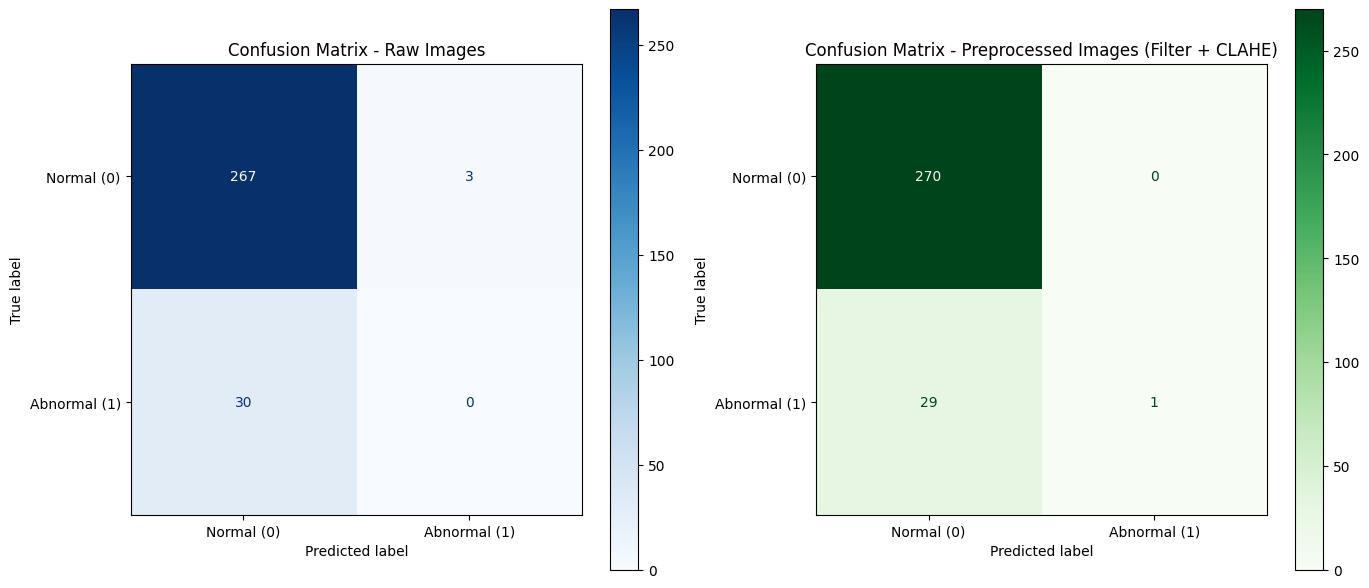

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrices
cm_raw = confusion_matrix(y_test, y_pred_raw)
cm_prep = confusion_matrix(y_test, y_pred_prep)

# Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw Images Confusion Matrix
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=['Normal (0)', 'Abnormal (1)'])
disp_raw.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Raw Images')

# Preprocessed Images Confusion Matrix
disp_prep = ConfusionMatrixDisplay(confusion_matrix=cm_prep, display_labels=['Normal (0)', 'Abnormal (1)'])
disp_prep.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Confusion Matrix - Preprocessed Images (Filter + CLAHE)')

plt.tight_layout()
plt.show()